##  This notebook provides all metrics that we use to compare final performance of models later.

In [2]:
"""
=================== Import required libraries ===================
"""

import time
import csv
import ast
import os
import yaml
import pickle
import random
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import joypy

import seaborn as sns
# import more_itertools
# import geopandas as gpd
import matplotlib as mpl
from pathlib import Path
from typing import Tuple
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.image import imread

from matplotlib.colors import ListedColormap
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
from scipy.stats import f_oneway

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import gaussian_kde  

In [5]:
'''
    To load all simulations for two modelling approaches
    (Ensemble of Top 10 configs post Random search (final 10 models trained each on 10 random seeds)
    and Ensemble of Top-3 regional configs in each of the 6 clusters (final 18 models, trained each on 10 random seeds))
    and the Benchmark from Kratzert 2024
'''

def find_dir_up(start: Path, dirname: str) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        d = p / dirname
        if d.exists() and d.is_dir():
            return d
    raise FileNotFoundError(f"Could not find '{dirname}' from {start}")

PICKLE_DIR = find_dir_up(Path.cwd().parent, "Pickles")
print("Using PICKLE_DIR:", PICKLE_DIR)

def load_pickle(p: Path):
    with p.open("rb") as f:
        return pickle.load(f)

ntLSTMsonSBs    = load_pickle(PICKLE_DIR / "ntLSTMsonSBs_CAMELSUS_test.p")
Cluster_wise    = load_pickle(PICKLE_DIR / "ensemble_Cluster_wise_CAMELSUS_test.p")
Top10           = load_pickle(PICKLE_DIR / "ensemble_Top10_CAMELSUS_test.p")
Obs_loaded      = load_pickle(PICKLE_DIR / "Obs_test.p")


Using PICKLE_DIR: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles


In [ ]:
# To check Never Train an LSTM on a Single Basin Paper Predictions (Benchmark) simulations shape

print(ntLSTMsonSBs.keys())
print(ntLSTMsonSBs['01022500'].keys())
print(ntLSTMsonSBs['01022500']['191889'].keys())
print(ntLSTMsonSBs['01022500']['191889']['QObs(mm/d)_sim'])


dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [ ]:
# To check Top10 Ensemble Predictions simulations shape

print(Top10.keys())
print(Top10['01022500'].keys())
print(Top10['01022500']['191889'].keys())
print(Top10['01022500']['191889']['ensemble'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [ ]:
# To check Cluster_wise Ensemble Predictions simulations shape

print(Cluster_wise.keys())
print(Cluster_wise['01022500'].keys())
print(Cluster_wise['01022500']['191889'].keys())
print(Cluster_wise['01022500']['191889']['ensemble'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [ ]:
# To check Observations shape

print(Obs_loaded.keys())
print(Obs_loaded['01022500'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [3]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path
from types import ModuleType
from typing import Optional


def import_module_from_path(
    module_name: str,
    file_path: Path,
    *,
    add_parent_to_syspath: bool = True
) -> ModuleType:
    """
    Import a module from an explicit file path (safe + notebook-friendly).

    Parameters
    ----------
    module_name : str
        Name to register the module under (e.g., "metrics").
    file_path : Path
        Path to the .py file.
    add_parent_to_syspath : bool
        If True, ensures the module's parent directory is in sys.path
        (helps if metrics.py does relative/local imports).
    """
    file_path = Path(file_path).resolve()

    if not file_path.exists():
        raise FileNotFoundError(f"Module file not found: {file_path}")
    if file_path.suffix.lower() != ".py":
        raise ValueError(f"Expected a .py file, got: {file_path}")

    parent_dir = str(file_path.parent)
    if add_parent_to_syspath and parent_dir not in sys.path:
        sys.path.insert(0, parent_dir)

    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not create import spec for: {file_path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module  # register so it can be imported elsewhere

    spec.loader.exec_module(module)
    return module


# -------------------------------------------------------------------
# Usage
# -------------------------------------------------------------------

# If metrics.py is in the same folder as your notebook's working dir:
metrics_file_path = Path.cwd() / "metrics.py"

# Or (more robust) search upward for your project root folder and point to it:
# PROJECT_DIR = find_dir_up(Path.cwd(), "codes")  # if you have such a folder
# metrics_file_path = PROJECT_DIR / "metrics.py"

metrics = import_module_from_path("metrics", metrics_file_path)
print("✅ Imported metrics from:", metrics.__file__)


✅ Imported metrics from: F:\Experiments\CAMELS_US\Clean_4_upload\codes\metrics.py


2026-02-09 11:11:18,649 | INFO | Output directory: F:\Experiments\CAMELS_US\Clean_4_upload\results
2026-02-09 11:11:18,794 | INFO | Top10: band computed from 10 seeds | mean NSE (valid seeds) = 0.958
2026-02-09 11:11:18,883 | INFO | Cluster-wise: band computed from 10 seeds | mean NSE (valid seeds) = 0.966
2026-02-09 11:11:18,979 | INFO | Benchmark: band computed from 10 seeds | mean NSE (valid seeds) = 0.902


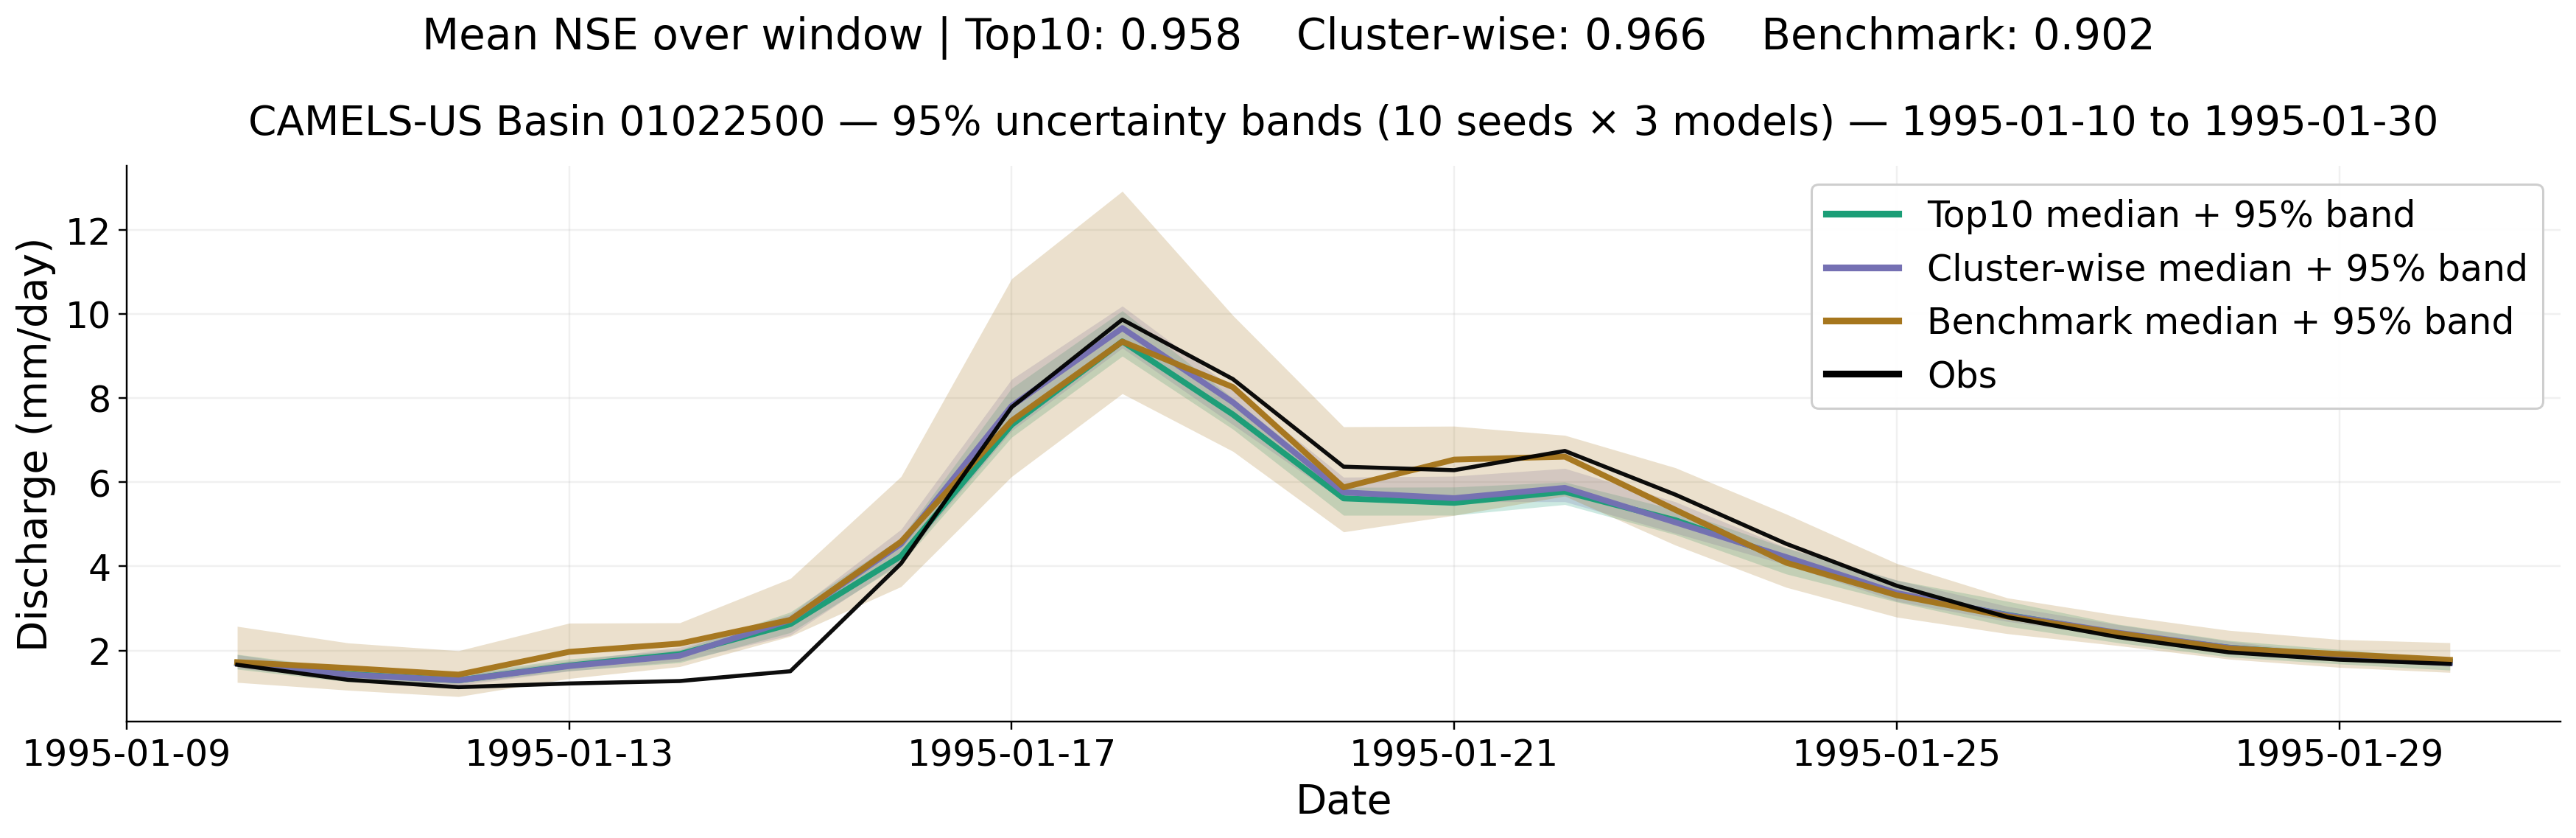

2026-02-09 11:11:20,855 | INFO | ✅ Saved:
- F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1995-01-10_to_1995-01-30.png
- F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1995-01-10_to_1995-01-30.pdf


Saved PNG: F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1995-01-10_to_1995-01-30.png
Saved PDF: F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1995-01-10_to_1995-01-30.pdf


In [6]:
from __future__ import annotations

import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, List

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# assumes `metrics` is already imported in your notebook runtime from metrics.py
# and that Obs_loaded, Top10, Cluster_wise, ntLSTMsonSBs are already loaded dicts

LOGGER = logging.getLogger("p95_hydrograph_plot")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


# -------------------------
# Config
# -------------------------
@dataclass(frozen=True)
class PlotConfig:
    basin_id: str = "01022500"
    start_date: Optional[str] = None
    end_date: Optional[str] = None

    out_dir: Path = Path.cwd().parent / "results"
    dpi: int = 220
    figsize: Tuple[float, float] = (16.0, 5.2)

    # Obs
    obs_lw: float = 1.8
    obs_alpha: float = 0.95

    # Median line
    median_lw: float = 2.6
    median_alpha: float = 0.98

    # 95% band
    band_alpha: float = 0.22

    grid_alpha: float = 0.18
    y_label: str = "Discharge (mm/day)"

    # CI definition
    q_low: float = 0.025
    q_high: float = 0.975

    # Typography (easy knobs)
    title_fs: int = 18
    label_fs: int = 18
    tick_fs: int = 16
    legend_fs: int = 16

    # Top NSE line
    suptitle_fs: int = 19
    suptitle_y: float = 0.985   # move up/down
    top_rect: Tuple[float, float, float, float] = (0.0, 0.0, 1.0, 0.99)  # reserve space


CFG = PlotConfig(
    basin_id="01022500",
    # start_date="1989-10-01",
    # end_date="1999-09-30",
    # start_date="1993-04-10",
    # end_date="1993-04-16",
    start_date="1995-01-10", 
    end_date="1995-01-30",
    # basin_id="14182500",
    # start_date="1995-10-01",
    # end_date="1996-09-30",
    # start_date="1996-02-05",
    # end_date="1996-02-10",
)

# NEW STRUCTURE for all models: Basins -> Seeds -> Preds
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Benchmark": "QObs(mm/d)_sim",
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
}

# Print-friendly palette (your current good-looking one; keep if you like)
MODEL_COLORS: Dict[str, str] = {
    "Top10": "#1b9e77",        # green-ish
    "Cluster-wise": "#7570b3", # purple-ish
    "Benchmark": "#a6761d",    # brown/gold
}


# -------------------------
# Helpers
# -------------------------
def ensure_2d(da: xr.DataArray) -> xr.DataArray:
    return da.expand_dims({"time_step": [0]}) if da.ndim == 1 else da


def to_1d(da: xr.DataArray) -> xr.DataArray:
    """
    Convert (date, time_step=1) -> (date,) safely, so metrics.py masking works.
    """
    if "time_step" in da.dims and da.sizes.get("time_step", 1) == 1:
        return da.isel(time_step=0, drop=True)
    if da.ndim == 2 and da.shape[1] == 1:
        return da.squeeze(drop=True)
    return da


def clip(da: xr.DataArray, start: Optional[str], end: Optional[str]) -> xr.DataArray:
    if "date" not in da.coords or (start is None and end is None):
        return da
    return da.sel(date=slice(start, end))


def align(obs: xr.DataArray, sim: xr.DataArray) -> Tuple[xr.DataArray, xr.DataArray]:
    obs = ensure_2d(obs)
    sim = ensure_2d(sim)
    obs, sim = xr.align(obs, sim, join="inner")
    if obs.shape != sim.shape:
        raise RuntimeError(f"Shape mismatch after align: obs={obs.shape}, sim={sim.shape}")
    return obs, sim


def sort_seeds(seed_keys) -> List[str]:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def get_model_seeds_for_basin(model_name: str, model_dict: Dict[str, Any], basin_id: str) -> List[str]:
    """
    NEW STRUCTURE: model_dict[basin_id] -> dict[seed] -> preds
    """
    if basin_id not in model_dict:
        raise KeyError(f"{model_name}: basin {basin_id} not found (expected Basins->Seeds->Preds).")
    if not isinstance(model_dict[basin_id], dict):
        raise TypeError(f"{model_name}: model_dict[{basin_id!r}] expected dict of seeds, got {type(model_dict[basin_id])}")
    return sort_seeds(model_dict[basin_id].keys())


def stack_seed_sims_for_model_and_nse(
    model_name: str,
    model_dict: Dict[str, Any],
    basin_id: str,
    series_key: str,
    obs_ref: xr.DataArray,
    start_date: Optional[str],
    end_date: Optional[str],
) -> Tuple[np.ndarray, float]:
    """
    Returns:
      sims_arr: (n_seeds, T) aligned to obs_ref
      mean_nse: mean over seeds (computed on the SAME window), using metrics.py
    """
    seeds = get_model_seeds_for_basin(model_name, model_dict, basin_id)

    sims_1d = []
    nse_vals = []

    for seed in seeds:
        payload = model_dict[basin_id][seed]
        if series_key not in payload:
            raise KeyError(f"{model_name}: missing '{series_key}' under basin={basin_id}, seed={seed}. Keys={list(payload.keys())}")

        sim = payload[series_key]
        if not isinstance(sim, xr.DataArray):
            raise TypeError(f"{model_name}: [{basin_id}][{seed}]['{series_key}'] must be DataArray, got {type(sim)}")

        sim = clip(ensure_2d(sim), start_date, end_date)
        obs_al, sim_al = align(obs_ref, sim)

        # For plotting bands we use 1D vectors
        obs_1d = to_1d(obs_al)
        sim_1d = to_1d(sim_al)

        sims_1d.append(sim_1d.values.astype(float).reshape(-1))

        # NSE per seed using metrics.py (MUST be 1D to avoid 2D boolean indexing)
        try:
            nse_seed = float(metrics.nse(obs_1d, sim_1d))
            if np.isfinite(nse_seed):
                nse_vals.append(nse_seed)
        except Exception as e:
            LOGGER.warning("NSE failed for %s seed=%s basin=%s | %r", model_name, seed, basin_id, e)

    sims_arr = np.stack(sims_1d, axis=0)  # (n_seeds, T)
    mean_nse = float(np.nan) if len(nse_vals) == 0 else float(np.mean(nse_vals))
    return sims_arr, mean_nse


# -------------------------
# Main plotter
# -------------------------
def plot_p95_hydrographs(cfg: PlotConfig) -> Tuple[Path, Path]:
    cfg.out_dir.mkdir(parents=True, exist_ok=True)
    LOGGER.info("Output directory: %s", cfg.out_dir.resolve())

    if cfg.basin_id not in Obs_loaded:
        raise KeyError(f"Obs_loaded missing basin {cfg.basin_id}")

    # Obs reference
    obs = clip(ensure_2d(Obs_loaded[cfg.basin_id]), cfg.start_date, cfg.end_date)
    obs_1d = to_1d(obs)
    date_index = obs_1d["date"].values
    obs_y = obs_1d.values.astype(float).reshape(-1)

    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)

    # --- typography
    ax.tick_params(axis="both", labelsize=cfg.tick_fs)

    # Obs on top
    ax.plot(
        date_index,
        obs_y,
        color="black",
        lw=cfg.obs_lw,
        alpha=cfg.obs_alpha,
        zorder=6,
    )

    # Bands + median per model
    mean_nse_by_model: Dict[str, float] = {}

    for model_name, model_dict in MODEL_SOURCES.items():
        color = MODEL_COLORS[model_name]
        key = SERIES_KEY[model_name]

        sims, mean_nse = stack_seed_sims_for_model_and_nse(
            model_name=model_name,
            model_dict=model_dict,
            basin_id=cfg.basin_id,
            series_key=key,
            obs_ref=obs,
            start_date=cfg.start_date,
            end_date=cfg.end_date,
        )
        mean_nse_by_model[model_name] = mean_nse

        q_low = np.nanquantile(sims, cfg.q_low, axis=0)
        q_high = np.nanquantile(sims, cfg.q_high, axis=0)
        med = np.nanmedian(sims, axis=0)

        ax.fill_between(
            date_index,
            q_low,
            q_high,
            color=color,
            alpha=cfg.band_alpha,
            linewidth=0.0,
            zorder=2,
        )
        ax.plot(
            date_index,
            med,
            color=color,
            lw=cfg.median_lw,
            alpha=cfg.median_alpha,
            zorder=5,
        )

        LOGGER.info("%s: band computed from %d seeds | mean NSE (valid seeds) = %s",
                    model_name, sims.shape[0],
                    "nan" if not np.isfinite(mean_nse) else f"{mean_nse:.3f}")

    # --- top NSE line (single, non-overlapping)
    def _fmt(v: float) -> str:
        return "nan" if not np.isfinite(v) else f"{v:.3f}"

    top_line = (
        f"Mean NSE over window | "
        f"Top10: {_fmt(mean_nse_by_model.get('Top10', np.nan))}    "
        f"Cluster-wise: {_fmt(mean_nse_by_model.get('Cluster-wise', np.nan))}    "
        f"Benchmark: {_fmt(mean_nse_by_model.get('Benchmark', np.nan))}"
    )
    fig.suptitle(top_line, fontsize=cfg.suptitle_fs, y=cfg.suptitle_y)

    # Title
    window_txt = ""
    if cfg.start_date or cfg.end_date:
        s = cfg.start_date if cfg.start_date else str(date_index[0])[:10]
        e = cfg.end_date if cfg.end_date else str(date_index[-1])[:10]
        window_txt = f" — {s} to {e}"

    ax.set_title(
        f"CAMELS-US Basin {cfg.basin_id} — 95% uncertainty bands (10 seeds × 3 models){window_txt}",
        pad=14,
        fontsize=cfg.title_fs,
    )
    ax.set_xlabel("Date", fontsize=cfg.label_fs)
    ax.set_ylabel(cfg.y_label, fontsize=cfg.label_fs)

    ax.grid(True, which="major", alpha=cfg.grid_alpha)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Line2D([0], [0], color=MODEL_COLORS["Top10"], lw=3.0, label="Top10 median + 95% band"),
        Line2D([0], [0], color=MODEL_COLORS["Cluster-wise"], lw=3.0, label="Cluster-wise median + 95% band"),
        Line2D([0], [0], color=MODEL_COLORS["Benchmark"], lw=3.0, label="Benchmark median + 95% band"),
        Line2D([0], [0], color="black", lw=3.0, label="Obs"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True, framealpha=0.95, fontsize=cfg.legend_fs)

    # IMPORTANT: keep space for suptitle (top NSE text)
    fig.tight_layout(rect=list(cfg.top_rect))

    # Save
    tag = f"{cfg.basin_id}_p95_3models"
    if cfg.start_date or cfg.end_date:
        tag += f"_{cfg.start_date or 'start'}_to_{cfg.end_date or 'end'}"

    png_path = cfg.out_dir / f"hydrograph_{tag}.png"
    pdf_path = cfg.out_dir / f"hydrograph_{tag}.pdf"

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    LOGGER.info("✅ Saved:\n- %s\n- %s", png_path.resolve(), pdf_path.resolve())
    return png_path, pdf_path


# -------------------------
# Run
# -------------------------
png_path, pdf_path = plot_p95_hydrographs(CFG)
print("Saved PNG:", png_path.resolve())
print("Saved PDF:", pdf_path.resolve())


In [39]:
# ============================================================
# Compute all metrics (metrics.py) for 3 CAMELS-US models
# Over full test period, per basin, per seed.
#
# NEW INPUT pickle structure (ALL MODELS):
#   model_dict[basin_id][seed_id][series_key] -> xr.DataArray
#
# OUTPUT pickle structure (unchanged):
#   results[basin_id][seed_id][model_name] = {metric_name: value, ...}
#
# Saved to: ./Pickles/metrics_all_test_period.p
#
# Notes / fixes included:
# 1) Forces 1D series (time,) to avoid "2-dimensional boolean indexing is not supported"
# 2) Explicitly computes Peak-Timing and Missed-Peaks with a non-None window
#    (fixes: "unsupported operand type(s) for -: 'int' and 'NoneType'")
# 3) Logs full metric line every LOG_EVERY_EVALS evaluations
# ============================================================

from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple, Optional, List

import numpy as np
import xarray as xr

# ------------------------------------------------------------------
# Assumes in your notebook runtime:
#   - `metrics` module is already imported (your metrics.py)
#   - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded are loaded dicts
# ------------------------------------------------------------------

LOGGER = logging.getLogger("metrics_all_test_period")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

LOG_EVERY_EVALS = 50  # change to 25/100 if you want

# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    """Try a few sensible locations relative to the notebook."""
    candidates = [
        Path.cwd() / fname,         # same folder as notebook
        Path.cwd().parent / fname,  # one level up
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

OUT_DIR = Path.cwd().parent / "Pickles"   
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "metrics_all_test_period.p"

# -------------------------
# Models (NEW basin-first dicts)
#   model_dict[basin_id][seed_id][series_key] -> DataArray
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

# ============================================================
# Helpers
# ============================================================
def read_basin_list(path: Path) -> List[str]:
    basins: List[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> List[str]:
    """Seeds are strings like '328237' or ints; sort numerically when possible."""
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    """
    Convert common containers to DataArray.
    If ndarray: accept (T,) or (T,1) and convert to 1D (T,).
    """
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, *, datetime_coord: str = "date") -> xr.DataArray:
    """
    Force a 1D (time,) DataArray to avoid metrics.py 2D boolean indexing issues.
    If da is (date, time_step=1), squeeze it to (date,).
    """
    da = _as_dataarray(da, name="series")

    # Squeeze common singleton time_step dim
    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    # Squeeze any other singleton dims
    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series after squeeze, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Series missing datetime coord '{datetime_coord}'. Available coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    """Align obs/sim on intersection of datetime_coord and ensure both are 1D."""
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)

    obs_al, sim_al = xr.align(obs1, sim1, join="inner")

    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")

    return obs_al, sim_al


def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    """
    Returns (peak_timing_window, missed_peaks_window).
    For daily CAMELS-US, Peak-Timing window=3 days and Missed-Peaks window=1 day
    is a sensible/standard choice.
    """
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24   # 3 days / 1 day
    if resolution in ("3H", "180min"):
        return 24, 8    # 3 days / 1 day in 3H steps
    return 3, 1


def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    """
    Safe wrapper:
      - forces 1D-aligned series
      - calls metrics.calculate_metrics for all metrics EXCEPT Peak-Timing/Missed-Peaks
      - computes Peak-Timing and Missed-Peaks with explicit (non-None) window
    """
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al,
        sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)

    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al,
        sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al,
        sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )

    return out


def get_model_seeds_for_basin(
    model_name: str,
    model_dict: Any,
    basin_id: str,
) -> List[str]:
    """
    NEW STRUCTURE:
        model_dict[basin_id] -> dict[seed_id] -> preds
    """
    if basin_id not in model_dict:
        raise KeyError(f"{model_name}: basin {basin_id} not found at top level (expected Basins->Seeds->Preds).")
    if not isinstance(model_dict[basin_id], dict):
        raise TypeError(f"{model_name}: model_dict[{basin_id!r}] expected dict of seeds, got {type(model_dict[basin_id])}")
    return sort_seeds(model_dict[basin_id].keys())


# ============================================================
# Main compute (BASIN-FIRST INPUTS)
# ============================================================
def compute_metrics_basin_first(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[str, Dict[str, Dict[str, Dict[str, float]]]]:
    """
    Output:
      results[basin_id][seed_id][model_name] = {metric_name: value}
    """
    metric_list = list(metrics.get_available_metrics())
    basins = list(basins)

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info("Logging every %d evaluations (basin×seed×model).", LOG_EVERY_EVALS)

    results: Dict[str, Dict[str, Dict[str, Dict[str, float]]]] = {}

    missing_obs = 0
    missing_pairs = 0
    eval_count = 0  # basin × seed × model

    # Optional: quick check if each model looks basin-first
    for model_name, model_dict in model_sources.items():
        if not isinstance(model_dict, dict):
            LOGGER.warning("Model '%s' is not a dict (got %s).", model_name, type(model_dict))

    for i, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs = obs_dict[basin_id]
        results.setdefault(basin_id, {})

        for model_name, model_dict in model_sources.items():
            series_key = series_key_by_model[model_name]

            try:
                seeds = get_model_seeds_for_basin(model_name, model_dict, basin_id)
            except Exception as e:
                # If a model is missing that basin entirely, mark all seeds as missing (no seed list to iterate)
                missing_pairs += 1
                LOGGER.warning("Model basin missing | basin=%s model=%s | %s", basin_id, model_name, str(e))
                continue

            if len(seeds) != 10:
                LOGGER.warning("Model '%s' basin=%s: expected 10 seeds, found %d.", model_name, basin_id, len(seeds))

            for seed in seeds:
                seed_id = str(seed)
                results[basin_id].setdefault(seed_id, {})

                try:
                    payload = model_dict[basin_id][seed]
                    if not isinstance(payload, dict):
                        raise TypeError(f"Expected dict at model_dict[{basin_id}][{seed_id}], got {type(payload)}")

                    if series_key not in payload:
                        raise KeyError(
                            f"Missing '{series_key}' for basin {basin_id} under seed {seed_id}. "
                            f"Available keys: {list(payload.keys())}"
                        )

                    sim = payload[series_key]

                    m = calculate_all_metrics_safe(
                        obs,
                        sim,
                        resolution=resolution,
                        datetime_coord=datetime_coord,
                    )

                except Exception as e:
                    missing_pairs += 1
                    LOGGER.warning(
                        "Metrics failed | basin=%s model=%s seed=%s | %s",
                        basin_id, model_name, seed_id, str(e)
                    )
                    m = {k: float("nan") for k in metric_list}

                results[basin_id][seed_id][model_name] = m

                eval_count += 1
                if (eval_count % LOG_EVERY_EVALS) == 0:
                    metrics_str = " | ".join(f"{k}={m.get(k, float('nan')):.4f}" for k in metric_list)
                    LOGGER.info(
                        "Eval %d | basin=%s | model=%s | seed=%s | %s",
                        eval_count, basin_id, model_name, seed_id, metrics_str
                    )

        if (i % 25) == 0 or (i == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | missing_pairs=%d",
                i, len(basins), eval_count, missing_pairs
            )

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed basin-seed-model evaluations: %d", missing_pairs)
    return results


# ============================================================
# RUN
# ============================================================
basin_list = read_basin_list(BASIN_LIST_PATH)

metrics_results = compute_metrics_basin_first(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",        # CAMELS-US daily
    datetime_coord="date",  # your DataArrays use coord 'date'
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(metrics_results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved metrics pickle to: %s", OUT_PATH.resolve())
print("Saved to:", OUT_PATH.resolve())


2026-02-04 12:54:51,658 | INFO | Reading basin list from: F:\Experiments\CAMELS_US\Clean_4_upload\531_basin_list.txt
2026-02-04 12:54:51,665 | INFO | Basins: 531 | Models: 3
2026-02-04 12:54:51,666 | INFO | Metrics: 15 | resolution=1D | datetime_coord=date
2026-02-04 12:54:51,667 | INFO | Logging every 50 evaluations (basin×seed×model).
2026-02-04 12:55:06,594 | INFO | Eval 50 | basin=01031500 | model=Cluster-wise | seed=993061 | NSE=0.9085 | MSE=0.8595 | RMSE=0.9271 | KGE=0.9105 | Alpha-NSE=0.9618 | Pearson-r=0.9541 | Beta-KGE=1.0667 | Beta-NSE=0.0426 | FHV=-1.7225 | FMS=-11.9454 | FLV=36.3758 | Peak-Timing=0.1364 | Missed-Peaks=0.3400 | Peak-MAPE=15.8737 | MAPE=38.8750
2026-02-04 12:55:20,959 | INFO | Eval 100 | basin=01052500 | model=Top10 | seed=993061 | NSE=0.8609 | MSE=1.8211 | RMSE=1.3495 | KGE=0.8509 | Alpha-NSE=0.8852 | Pearson-r=0.9298 | Beta-KGE=0.9357 | Beta-NSE=-0.0406 | FHV=-9.9211 | FMS=-10.3672 | FLV=26.4309 | Peak-Timing=0.0455 | Missed-Peaks=0.4068 | Peak-MAPE=23.7769

Saved to: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\metrics_all_test_period.p


In [40]:
# ============================================================
# Compute all metrics (metrics.py) for 3 CAMELS-US models
# Per WATER YEAR (Oct 1 -> Sep 30), per basin, per seed.
#
# INPUT pickle structure (NEW):
#   model_dict[basin_id][seed_id][series_key] -> xarray.DataArray
#
# OUTPUT pickle structure:
#   results[water_year][basin_id][seed_id][model_name] = {metric_name: value, ...}
#
# Saved to: ../Pickles/metrics_by_water_year.p
#
# Fixes included:
# 1) Forces 1D series (time,) to avoid "2-dimensional boolean indexing is not supported"
# 2) Computes Peak-Timing and Missed-Peaks with explicit window (non-None)
# 3) Logs full metric line every LOG_EVERY_EVALS evaluations (WY×basin×seed×model)
# ============================================================

from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple

import numpy as np
import xarray as xr

# ------------------------------------------------------------------
# Assumes in your notebook runtime:
#   - `metrics` module is already imported (your metrics.py)
#   - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded are loaded dicts
# ------------------------------------------------------------------

LOGGER = logging.getLogger("metrics_by_water_year")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

LOG_EVERY_EVALS = 50      # log each N evaluations (WY×basin×seed×model)
MIN_POINTS_PER_WY = 30    # skip a water year slice if too short (set to 1 to disable)

# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [
        Path.cwd() / fname,
        Path.cwd().parent / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

# one step back, then Pickles
OUT_DIR = Path.cwd().parent / "Pickles"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "metrics_by_water_year.p"

# -------------------------
# Models (NEW basin-first dicts)
#   model_dict[basin_id][seed_id][series_key] -> DataArray
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

# ============================================================
# Helpers
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> list:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        # accept (T,) or (T,1) and convert to 1D
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, *, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")

    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series after squeeze, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Series missing datetime coord '{datetime_coord}'. Available coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")

    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")

    return obs_al, sim_al


def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1


def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al,
        sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )
    return out


def water_year_of_dates(dates: np.ndarray) -> np.ndarray:
    """
    CAMELS-US water year: Oct 1 -> Sep 30
    water_year = year + 1 if month >= 10 else year
    """
    dt = dates.astype("datetime64[D]")
    year = dt.astype("datetime64[Y]").astype(int) + 1970
    month = (dt.astype("datetime64[M]").astype(int) % 12) + 1
    return year + (month >= 10).astype(int)


def slice_to_water_year(
    da: xr.DataArray,
    wy: int,
    *,
    datetime_coord: str = "date",
) -> xr.DataArray:
    da1 = to_1d(da, datetime_coord=datetime_coord)
    start = f"{wy-1}-10-01"
    end = f"{wy}-09-30"
    return da1.sel({datetime_coord: slice(start, end)})


def get_model_seeds_for_basin(model_name: str, model_dict: Any, basin_id: str) -> list:
    """
    NEW STRUCTURE:
        model_dict[basin_id] -> dict[seed] -> payload
    """
    if basin_id not in model_dict:
        return []
    node = model_dict[basin_id]
    if not isinstance(node, dict):
        raise TypeError(f"{model_name}: expected dict at model_dict[{basin_id!r}], got {type(node)}")
    return sort_seeds(node.keys())


# ============================================================
# Main compute
# ============================================================
def compute_metrics_by_water_year_basin_first(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]]:
    """
    results[water_year][basin_id][seed_id][model_name] = {metric_name: value}
    """
    metric_list = list(metrics.get_available_metrics())
    basins = list(basins)

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info("Logging every %d evaluations (WY×basin×seed×model).", LOG_EVERY_EVALS)

    results: Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]] = {}
    missing_obs = 0
    missing_pairs = 0
    skipped_short = 0
    eval_count = 0

    for i, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs_full = to_1d(obs_dict[basin_id], datetime_coord=datetime_coord)
        dates = obs_full[datetime_coord].values
        wys = np.unique(water_year_of_dates(dates))

        for wy in wys:
            wy = int(wy)

            obs_wy = slice_to_water_year(obs_full, wy, datetime_coord=datetime_coord)
            if obs_wy.size < MIN_POINTS_PER_WY:
                skipped_short += 1
                continue

            results.setdefault(wy, {})
            results[wy].setdefault(basin_id, {})

            for model_name, model_dict in model_sources.items():
                series_key = series_key_by_model[model_name]

                # seeds for THIS basin (new structure)
                seeds = get_model_seeds_for_basin(model_name, model_dict, basin_id)
                if len(seeds) == 0:
                    # nothing for this basin in this model
                    continue
                if len(seeds) != 10:
                    LOGGER.warning("Model '%s' basin=%s: expected 10 seeds, found %d.", model_name, basin_id, len(seeds))

                for seed in seeds:
                    seed_id = str(seed)
                    results[wy][basin_id].setdefault(seed_id, {})

                    try:
                        basin_node = model_dict[basin_id]
                        if seed not in basin_node:
                            raise KeyError(f"Missing seed {seed_id} under basin {basin_id}")

                        payload = basin_node[seed]
                        if not isinstance(payload, dict):
                            raise TypeError(f"{model_name}: expected dict at [{basin_id}][{seed_id}], got {type(payload)}")

                        if series_key not in payload:
                            raise KeyError(
                                f"Missing '{series_key}' for model={model_name} basin={basin_id} seed={seed_id}. "
                                f"Available keys: {list(payload.keys())}"
                            )

                        sim_full = payload[series_key]
                        sim_wy = slice_to_water_year(sim_full, wy, datetime_coord=datetime_coord)

                        if sim_wy.size < MIN_POINTS_PER_WY:
                            raise ValueError(f"Too few sim points in WY{wy}: n={sim_wy.size}")

                        m = calculate_all_metrics_safe(
                            obs_wy,
                            sim_wy,
                            resolution=resolution,
                            datetime_coord=datetime_coord,
                        )

                    except Exception as e:
                        missing_pairs += 1
                        LOGGER.warning(
                            "Metrics failed | WY=%d basin=%s model=%s seed=%s | %s",
                            wy, basin_id, model_name, seed_id, str(e)
                        )
                        m = {k: float("nan") for k in metric_list}

                    results[wy][basin_id][seed_id][model_name] = m

                    eval_count += 1
                    if (eval_count % LOG_EVERY_EVALS) == 0:
                        metrics_str = " | ".join(f"{k}={m.get(k, float('nan')):.4f}" for k in metric_list)
                        LOGGER.info(
                            "Eval %d | WY=%d | basin=%s | model=%s | seed=%s | %s",
                            eval_count, wy, basin_id, model_name, seed_id, metrics_str
                        )

        if (i % 25) == 0 or (i == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | missing_pairs=%d | skipped_short=%d",
                i, len(basins), eval_count, missing_pairs, skipped_short
            )

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed WY-basin-seed-model evaluations: %d", missing_pairs)
    LOGGER.info("Skipped short WY slices (<%d pts): %d", MIN_POINTS_PER_WY, skipped_short)
    return results


# ============================================================
# RUN
# ============================================================
basin_list = read_basin_list(BASIN_LIST_PATH)

metrics_results = compute_metrics_by_water_year_basin_first(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(metrics_results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved metrics pickle to: %s", OUT_PATH.resolve())
print("Saved to:", OUT_PATH.resolve())


2026-02-04 13:58:35,595 | INFO | Reading basin list from: F:\Experiments\CAMELS_US\Clean_4_upload\531_basin_list.txt
2026-02-04 13:58:35,599 | INFO | Basins: 531 | Models: 3
2026-02-04 13:58:35,600 | INFO | Metrics: 15 | resolution=1D | datetime_coord=date
2026-02-04 13:58:35,601 | INFO | Logging every 50 evaluations (WY×basin×seed×model).
2026-02-04 13:58:39,793 | INFO | Eval 50 | WY=1991 | basin=01022500 | model=Cluster-wise | seed=993061 | NSE=0.8239 | MSE=0.7438 | RMSE=0.8624 | KGE=0.8457 | Alpha-NSE=0.9931 | Pearson-r=0.9206 | Beta-KGE=1.1321 | Beta-NSE=0.1352 | FHV=-4.0421 | FMS=-10.8709 | FLV=-8.5008 | Peak-Timing=0.0000 | Missed-Peaks=0.0000 | Peak-MAPE=13.3636 | MAPE=34.5697
2026-02-04 13:58:43,645 | INFO | Eval 100 | WY=1993 | basin=01022500 | model=Top10 | seed=993061 | NSE=0.9518 | MSE=0.3367 | RMSE=0.5803 | KGE=0.8918 | Alpha-NSE=0.9257 | Pearson-r=0.9781 | Beta-KGE=1.0755 | Beta-NSE=0.0451 | FHV=-7.4978 | FMS=-7.7884 | FLV=12.3771 | Peak-Timing=0.5000 | Missed-Peaks=0.200

Saved to: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\metrics_by_water_year.p


In [41]:
# ============================================================
# Compute all metrics (metrics.py) for 3 CAMELS-US models
# Per YEAR × SEASON, per basin, per seed.
#
# Seasons (fixed):
#   JFM = Jan-Feb-Mar
#   AMJ = Apr-May-Jun
#   JAS = Jul-Aug-Sep
#   OND = Oct-Nov-Dec
#
# INPUT pickle structure (NEW):
#   model_dict[basin_id][seed_id][series_key] -> xarray.DataArray
#
# OUTPUT pickle structure:
#   results[year][season][basin_id][seed_id][model_name] = {metric_name: value, ...}
#
# Saved to: ../Pickles/metrics_by_year_season.p
#
# Fixes:
# 1) Force 1D series (date,) to avoid 2D boolean indexing issues
# 2) Peak-Timing & Missed-Peaks computed with explicit windows
# 3) Logs full metric line every LOG_EVERY_EVALS evaluations
# 4) xarray.where uses a DataArray condition (not numpy bool array)
# ============================================================

from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple

import numpy as np
import xarray as xr

LOGGER = logging.getLogger("metrics_by_year_season")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

LOG_EVERY_EVALS = 300
MIN_POINTS_PER_SLICE = 15

SEASONS = ("JFM", "AMJ", "JAS", "OND")

# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [
        Path.cwd() / fname,
        Path.cwd().parent / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

# one step back, then Pickles
OUT_DIR = Path.cwd().parent / "Pickles"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "metrics_by_year_season.p"

# -------------------------
# Models (NEW basin-first dicts)
#   model_dict[basin_id][seed_id][series_key] -> DataArray
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

# ============================================================
# Helpers
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> list:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def get_model_seeds_for_basin(model_name: str, model_dict: Any, basin_id: str) -> list:
    """
    NEW STRUCTURE:
        model_dict[basin_id] -> dict[seed] -> payload
    """
    if basin_id not in model_dict:
        return []
    node = model_dict[basin_id]
    if not isinstance(node, dict):
        raise TypeError(f"{model_name}: expected dict at model_dict[{basin_id!r}], got {type(node)}")
    return sort_seeds(node.keys())


def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, *, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")

    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series after squeeze, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Series missing datetime coord '{datetime_coord}'. Available coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")
    return obs_al, sim_al


def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1


def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al,
        sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al,
        sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al,
        sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )
    return out


# -------------------------
# FIXED slicing utilities
# -------------------------
def season_of_month(month: xr.DataArray) -> xr.DataArray:
    """
    month: DataArray of ints [1..12]
    returns DataArray of season labels aligned with month.
    """
    season = xr.full_like(month, fill_value="", dtype=object)
    season = season.where(~((month >= 1) & (month <= 3)), other="JFM")
    season = season.where(~((month >= 4) & (month <= 6)), other="AMJ")
    season = season.where(~((month >= 7) & (month <= 9)), other="JAS")
    season = season.where(~((month >= 10) & (month <= 12)), other="OND")
    return season


def slice_to_year_season(
    da: xr.DataArray,
    year: int,
    season: str,
    *,
    datetime_coord: str = "date",
) -> xr.DataArray:
    """
    Slice da to points where (year == year) AND (season == season),
    using an xarray DataArray boolean mask (NOT numpy).
    """
    da1 = to_1d(da, datetime_coord=datetime_coord)

    dt = da1[datetime_coord].dt
    y = dt.year
    m = dt.month
    s = season_of_month(m)

    mask = (y == year) & (s == season)  # DataArray mask
    return da1.where(mask, drop=True)


# ============================================================
# Main compute
# ============================================================
def compute_metrics_by_year_season_basin_first(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]]:
    """
    results[year][season][basin_id][seed_id][model_name] = {metric_name: value}
    """
    metric_list = list(metrics.get_available_metrics())
    basins = list(basins)

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info("Seasons: %s", ",".join(SEASONS))
    LOGGER.info("Logging every %d evaluations.", LOG_EVERY_EVALS)

    results: Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]] = {}
    missing_obs = 0
    missing_pairs = 0
    skipped_short = 0
    eval_count = 0

    for i, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs_full = to_1d(obs_dict[basin_id], datetime_coord=datetime_coord)
        years = np.unique(obs_full[datetime_coord].dt.year.values).astype(int)

        for year in years:
            year = int(year)
            results.setdefault(year, {})

            for season in SEASONS:
                obs_slice = slice_to_year_season(obs_full, year, season, datetime_coord=datetime_coord)

                if obs_slice.size < MIN_POINTS_PER_SLICE:
                    skipped_short += 1
                    continue

                results[year].setdefault(season, {})
                results[year][season].setdefault(basin_id, {})

                for model_name, model_dict in model_sources.items():
                    series_key = series_key_by_model[model_name]

                    # seeds for this basin (NEW structure)
                    seeds = get_model_seeds_for_basin(model_name, model_dict, basin_id)
                    if len(seeds) == 0:
                        continue
                    if len(seeds) != 10:
                        LOGGER.warning("Model '%s' basin=%s: expected 10 seeds, found %d.", model_name, basin_id, len(seeds))

                    for seed in seeds:
                        seed_id = str(seed)
                        results[year][season][basin_id].setdefault(seed_id, {})

                        try:
                            basin_node = model_dict[basin_id]
                            if seed not in basin_node:
                                raise KeyError(f"Missing seed {seed_id} under basin {basin_id}")

                            payload = basin_node[seed]
                            if not isinstance(payload, dict):
                                raise TypeError(f"{model_name}: expected dict at [{basin_id}][{seed_id}], got {type(payload)}")

                            if series_key not in payload:
                                raise KeyError(
                                    f"Missing '{series_key}' for model={model_name} basin={basin_id} seed={seed_id}. "
                                    f"Available keys: {list(payload.keys())}"
                                )

                            sim_full = payload[series_key]
                            sim_slice = slice_to_year_season(sim_full, year, season, datetime_coord=datetime_coord)

                            if sim_slice.size < MIN_POINTS_PER_SLICE:
                                raise ValueError(f"Too few sim points in {year}-{season}: n={sim_slice.size}")

                            m = calculate_all_metrics_safe(
                                obs_slice,
                                sim_slice,
                                resolution=resolution,
                                datetime_coord=datetime_coord,
                            )

                        except Exception as e:
                            missing_pairs += 1
                            LOGGER.warning(
                                "Metrics failed | year=%d season=%s basin=%s model=%s seed=%s | %s",
                                year, season, basin_id, model_name, seed_id, str(e)
                            )
                            m = {k: float("nan") for k in metric_list}

                        results[year][season][basin_id][seed_id][model_name] = m

                        eval_count += 1
                        if (eval_count % LOG_EVERY_EVALS) == 0:
                            metrics_str = " | ".join(f"{k}={m.get(k, float('nan')):.4f}" for k in metric_list)
                            LOGGER.info(
                                "Eval %d | year=%d | season=%s | basin=%s | model=%s | seed=%s | %s",
                                eval_count, year, season, basin_id, model_name, seed_id, metrics_str
                            )

        if (i % 25) == 0 or (i == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | missing_pairs=%d | skipped_short=%d",
                i, len(basins), eval_count, missing_pairs, skipped_short
            )

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed evaluations: %d", missing_pairs)
    LOGGER.info("Skipped short slices (<%d pts): %d", MIN_POINTS_PER_SLICE, skipped_short)
    return results


# ============================================================
# RUN
# ============================================================
basin_list = read_basin_list(BASIN_LIST_PATH)

metrics_results = compute_metrics_by_year_season_basin_first(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(metrics_results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved metrics pickle to: %s", OUT_PATH.resolve())
print("Saved to:", OUT_PATH.resolve())


2026-02-04 17:13:41,438 | INFO | Reading basin list from: F:\Experiments\CAMELS_US\Clean_4_upload\531_basin_list.txt
2026-02-04 17:13:41,446 | INFO | Basins: 531 | Models: 3
2026-02-04 17:13:41,447 | INFO | Metrics: 15 | resolution=1D | datetime_coord=date
2026-02-04 17:13:41,448 | INFO | Seasons: JFM,AMJ,JAS,OND
2026-02-04 17:13:41,450 | INFO | Logging every 300 evaluations.
2026-02-04 17:14:02,797 | INFO | Eval 300 | year=1992 | season=JFM | basin=01022500 | model=Benchmark | seed=993061 | NSE=0.7683 | MSE=1.0363 | RMSE=1.0180 | KGE=0.7107 | Alpha-NSE=1.1447 | Pearson-r=0.9383 | Beta-KGE=1.2428 | Beta-NSE=0.2638 | FHV=31.8038 | FMS=-14.1171 | FLV=-105.2828 | Peak-Timing=1.0000 | Missed-Peaks=0.0000 | Peak-MAPE=18.9763 | MAPE=36.4285
2026-02-04 17:14:23,517 | INFO | Eval 600 | year=1994 | season=JAS | basin=01022500 | model=Benchmark | seed=993061 | NSE=-0.8750 | MSE=0.0144 | RMSE=0.1201 | KGE=0.3857 | Alpha-NSE=1.4066 | Pearson-r=0.6061 | Beta-KGE=1.2386 | Beta-NSE=0.7757 | FHV=43.31

Saved to: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\metrics_by_year_season.p


In [4]:
# ============================================================
# High-flow EVENTS metrics for 3 CAMELS-US models (DAILY)
#
# 1) Extract events from OBS:
#    - threshold = Q98 on OBS
#    - merge cores if (t - last_t) <= max_gap_days
#      (daily note: consecutive days => gap=1)
#    - discard cores < min_core_len_days
#    - expand eval window by pre_days / post_days
#
# 2) Compute metrics EVENT-WISE per basin/seed/model
# 3) Aggregate across events (nanmean) -> one metrics dict per basin/seed/model
#
# INPUT pickle structure (NEW):
#   model_dict[basin_id][seed_id][series_key] -> xr.DataArray
#
# OUTPUTS:
# A) Aggregated metrics:
#    results_agg[basin_id][seed_id][model_name] = {metric: value}
#    -> ../Pickles/metrics_highflow_events_allbasins.p
#
# B) Event-wise metrics:
#    results_events[basin_id][event_uid][seed_id][model_name] = {metric: value}
#    -> ../Pickles/metrics_highflow_events_eventwise.p
#
# C) Basin events log (raw):
#    -> ../Pickles/highflow_events_log.csv
#
# D) Basin events log with global IDs:
#    -> ../Pickles/highflow_events_log_with_global.csv
#
# E) Global event catalog:
#    -> ../Pickles/global_event_catalog.csv
#
# F) Global event index:
#    global_event_index[global_event_id] = list of membership dicts
#    -> ../Pickles/global_event_index.p
#
# G) Full run log:
#    -> ../Pickles/highflow_events_run.log
# ============================================================

from __future__ import annotations

import logging
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple, List

import numpy as np
import pandas as pd
import xarray as xr

# ------------------------------------------------------------------
# Assumes in your notebook runtime:
#   - `metrics` module already imported (your metrics.py)
#   - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded are loaded dicts
#   - NEW basin-first dicts:
#       model_dict[basin_id][seed_id][series_key] -> xr.DataArray
# ------------------------------------------------------------------

# -------------------------
# Output paths (one step back, then Pickles)
# -------------------------
OUT_DIR = Path.cwd().parent / "Pickles"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_LOG_PATH = OUT_DIR / "highflow_events_run.log"

LOGGER = logging.getLogger("metrics_highflow_events")
LOGGER.setLevel(logging.INFO)

_sh = logging.StreamHandler()
_sh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))

_fh = logging.FileHandler(RUN_LOG_PATH, mode="w", encoding="utf-8")
_fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))

if not LOGGER.handlers:
    LOGGER.addHandler(_sh)
    LOGGER.addHandler(_fh)

LOG_EVERY_EVALS = 500  # detailed metrics log every N event-evals


# ============================================================
# EVENT DEFINITION (DAILY)
# ============================================================
@dataclass(frozen=True)
class EventConfig:
    q_high_pctl: float = 0.98
    max_gap_days: int = 1
    min_core_len_days: int = 1
    pre_days: int = 1
    post_days: int = 1
    global_cluster_tolerance_days: int = 1

ECFG = EventConfig()


# -------------------------
# Basin list path
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [Path.cwd() / fname, Path.cwd().parent / fname]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

OUT_AGG_METRICS_PATH        = OUT_DIR / "metrics_highflow_events_allbasins.p"
OUT_EVENT_METRICS_PATH      = OUT_DIR / "metrics_highflow_events_eventwise.p"
OUT_EVENTS_LOG_RAW          = OUT_DIR / "highflow_events_log.csv"
OUT_EVENTS_LOG_WITH_GLOBAL  = OUT_DIR / "highflow_events_log_with_global.csv"
OUT_GLOBAL_CATALOG          = OUT_DIR / "global_event_catalog.csv"
OUT_GLOBAL_INDEX            = OUT_DIR / "global_event_index.p"


# -------------------------
# Models (NEW basin-first dicts)
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}


# ============================================================
# Helpers: IO / seeds
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> list:
    cleaned = []
    for k in seed_keys:
        s = str(k)
        if s.lower() == "ensemble":
            continue
        if s.isdigit():
            cleaned.append(k)
        elif isinstance(k, int):
            cleaned.append(k)

    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(cleaned, key=_k)


def get_model_seeds_for_basin(model_name: str, model_dict: Any, basin_id: str) -> list:
    """
    NEW STRUCTURE:
        model_dict[basin_id] -> dict[seed] -> payload
    """
    if basin_id not in model_dict:
        return []
    node = model_dict[basin_id]
    if not isinstance(node, dict):
        raise TypeError(f"{model_name}: expected dict at model_dict[{basin_id!r}], got {type(node)}")
    return sort_seeds(node.keys())


# ============================================================
# Helpers: xarray shaping (force 1D on 'date')
# ============================================================
def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")

    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Missing coord '{datetime_coord}'. Coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")
    return obs_al, sim_al


# ============================================================
# Metrics wrapper:
#   - fixes Peak-Timing / Missed-Peaks windows
#   - FIX: safe FHV to avoid division by zero
# ============================================================
def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1


def safe_fhv(obs_al: xr.DataArray, sim_al: xr.DataArray, eps: float = 1e-12) -> float:
    """
    FHV in your metrics.py is roughly:
        sum(sim - obs) / sum(obs)
    In event windows, sum(obs) can be ~0 -> NaN/inf and warnings.
    Here we guard it and return NaN when denominator is too small.
    """
    o = obs_al.values.astype(float)
    s = sim_al.values.astype(float)

    # ignore NaNs
    mask = np.isfinite(o) & np.isfinite(s)
    if not np.any(mask):
        return float("nan")

    denom = float(np.sum(o[mask]))
    if (not np.isfinite(denom)) or abs(denom) < eps:
        return float("nan")

    num = float(np.sum(s[mask] - o[mask]))
    return float(num / denom)


def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    # Suppress runtime warnings inside metric functions (FHV etc.)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        out = metrics.calculate_metrics(
            obs_al,
            sim_al,
            base_names,
            resolution=resolution,
            datetime_coord=datetime_coord,
        )

    # Explicit windows for these two
    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )

    # Override FHV with safe version (prevents sum(obs)==0 warnings)
    if "FHV" in all_names:
        out["FHV"] = safe_fhv(obs_al, sim_al)

    return out


# ============================================================
# Event extraction (daily)
# ============================================================
def detect_highflow_events_daily(
    times: pd.DatetimeIndex,
    hf_mask: np.ndarray,
    *,
    max_gap_days: int,
    min_core_len_days: int,
    pre_days: int,
    post_days: int,
    start_ts: pd.Timestamp,
    end_ts: pd.Timestamp,
) -> List[dict]:
    hf_times = times[hf_mask]
    if len(hf_times) == 0:
        return []

    core_intervals: List[Tuple[pd.Timestamp, pd.Timestamp]] = []
    current_start = pd.Timestamp(hf_times[0])
    last_t = pd.Timestamp(hf_times[0])

    for t in hf_times[1:]:
        t = pd.Timestamp(t)
        gap_days = (t - last_t) / pd.Timedelta(days=1)
        if gap_days <= max_gap_days:
            last_t = t
        else:
            core_intervals.append((current_start, last_t))
            current_start = t
            last_t = t

    core_intervals.append((current_start, last_t))

    events: List[dict] = []
    event_id = 0

    for core_s, core_e in core_intervals:
        core_len_days = int(((core_e - core_s) / pd.Timedelta(days=1)) + 1)
        if core_len_days < min_core_len_days:
            continue

        win_s = max(core_s - pd.Timedelta(days=pre_days), start_ts)
        win_e = min(core_e + pd.Timedelta(days=post_days), end_ts)

        events.append({
            "event_local_id": event_id,
            "t_core_start": core_s,
            "t_core_end": core_e,
            "t_start": win_s,
            "t_end": win_e,
            "core_len_days": core_len_days,
            "win_len_days": int(((win_e - win_s) / pd.Timedelta(days=1)) + 1),
        })
        event_id += 1

    return events


def slice_event(
    obs1: xr.DataArray,
    sim1: xr.DataArray,
    t0: pd.Timestamp,
    t1: pd.Timestamp,
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs_ev = obs1.sel(date=slice(t0, t1))
    sim_ev = sim1.sel(date=slice(t0, t1))
    obs_ev, sim_ev = xr.align(obs_ev, sim_ev, join="inner")
    return obs_ev, sim_ev


def aggregate_event_metrics(event_metrics: List[Dict[str, float]], metric_list: List[str]) -> Dict[str, float]:
    if len(event_metrics) == 0:
        return {k: float("nan") for k in metric_list}
    out: Dict[str, float] = {}
    for k in metric_list:
        vals = np.array([m.get(k, np.nan) for m in event_metrics], dtype=float)
        out[k] = float(np.nanmean(vals)) if np.any(~np.isnan(vals)) else float("nan")
    return out


# ============================================================
# Global event clustering (time overlap)
# ============================================================
def assign_global_event_ids(
    events_df: pd.DataFrame,
    *,
    tolerance_days: int,
) -> Tuple[pd.DataFrame, Dict[int, List[dict]]]:
    if events_df.empty:
        out = events_df.copy()
        out["global_event_id"] = pd.Series(dtype=int)
        return out, {}

    df = events_df.copy()
    df["win_start"] = pd.to_datetime(df["win_start"])
    df["win_end"] = pd.to_datetime(df["win_end"])

    tol = pd.Timedelta(days=tolerance_days)
    df["start_exp"] = df["win_start"] - tol
    df["end_exp"] = df["win_end"] + tol

    df = df.sort_values(["start_exp", "end_exp"]).reset_index(drop=True)

    gids = []
    gid = 0
    cur_end = df.loc[0, "end_exp"]
    gids.append(gid)

    for i in range(1, len(df)):
        s = df.loc[i, "start_exp"]
        e = df.loc[i, "end_exp"]
        if s <= cur_end:
            gids.append(gid)
            if e > cur_end:
                cur_end = e
        else:
            gid += 1
            gids.append(gid)
            cur_end = e

    df["global_event_id"] = gids

    global_index: Dict[int, List[dict]] = {}
    for g, gdf in df.groupby("global_event_id"):
        global_index[int(g)] = [
            {
                "basin_id": r["basin_id"],
                "event_uid": r["event_uid"],
                "win_start": r["win_start"],
                "win_end": r["win_end"],
                "core_start": r["core_start"],
                "core_end": r["core_end"],
            }
            for _, r in gdf.iterrows()
        ]

    df = df.drop(columns=["start_exp", "end_exp"])
    return df, global_index


# ============================================================
# MAIN
# ============================================================
def compute_metrics_on_highflow_events_basin_first(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Tuple[
    Dict[str, Dict[str, Dict[str, Dict[str, float]]]],
    Dict[str, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]],
    pd.DataFrame,
]:
    basins = list(basins)
    metric_list = list(metrics.get_available_metrics())

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info(
        "Event def: Q%.0f | max_gap_days=%d | min_core_len_days=%d | pre_days=%d | post_days=%d",
        ECFG.q_high_pctl * 100, ECFG.max_gap_days, ECFG.min_core_len_days, ECFG.pre_days, ECFG.post_days
    )

    results_agg: Dict[str, Dict[str, Dict[str, Dict[str, float]]]] = {}
    results_events: Dict[str, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]] = {}
    events_rows: List[dict] = []

    missing_obs = 0
    missing_pairs = 0
    eval_count = 0

    for bi, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs_raw = obs_dict[basin_id]
        obs1 = to_1d(obs_raw, datetime_coord=datetime_coord)
        times = pd.DatetimeIndex(obs1[datetime_coord].values)

        start_ts = pd.Timestamp(times.min())
        end_ts = pd.Timestamp(times.max())

        obs_vals = obs1.values.astype(float)
        if np.all(np.isnan(obs_vals)):
            events = []
            thr = np.nan
        else:
            thr = float(np.nanquantile(obs_vals, ECFG.q_high_pctl))
            hf_mask = np.asarray(obs_vals >= thr, dtype=bool)
            events = detect_highflow_events_daily(
                times,
                hf_mask,
                max_gap_days=ECFG.max_gap_days,
                min_core_len_days=ECFG.min_core_len_days,
                pre_days=ECFG.pre_days,
                post_days=ECFG.post_days,
                start_ts=start_ts,
                end_ts=end_ts,
            )

        results_agg.setdefault(basin_id, {})
        results_events.setdefault(basin_id, {})

        for ev in events:
            event_uid = f"{basin_id}__E{ev['event_local_id']:03d}__{ev['t_core_start'].date()}__{ev['t_core_end'].date()}"
            ev["event_uid"] = event_uid

            events_rows.append({
                "basin_id": basin_id,
                "event_uid": event_uid,
                "event_local_id": ev["event_local_id"],
                "threshold_q": ECFG.q_high_pctl,
                "threshold_value": thr,
                "core_start": ev["t_core_start"],
                "core_end": ev["t_core_end"],
                "win_start": ev["t_start"],
                "win_end": ev["t_end"],
                "core_len_days": ev["core_len_days"],
                "win_len_days": ev["win_len_days"],
            })

        for model_name, model_dict in model_sources.items():
            series_key = series_key_by_model[model_name]
            seeds = get_model_seeds_for_basin(model_name, model_dict, basin_id)

            if len(seeds) == 0:
                continue
            if len(seeds) != 10:
                LOGGER.warning("Model '%s' basin=%s: expected 10 seeds, found %d.", model_name, basin_id, len(seeds))

            for seed in seeds:
                seed_id = str(seed)
                results_agg[basin_id].setdefault(seed_id, {})

                try:
                    basin_node = model_dict[basin_id]
                    if seed not in basin_node:
                        raise KeyError(f"Missing seed {seed_id} under basin {basin_id}")

                    payload = basin_node[seed]
                    if series_key not in payload:
                        raise KeyError(
                            f"Missing '{series_key}' for model={model_name} basin={basin_id} seed={seed_id}. "
                            f"Keys={list(payload.keys())}"
                        )

                    sim_raw = payload[series_key]

                    obs_al, sim_al = align_obs_sim_1d(obs_raw, sim_raw, datetime_coord=datetime_coord)

                    ev_metrics_list: List[Dict[str, float]] = []

                    for ev in events:
                        results_events[basin_id].setdefault(ev["event_uid"], {}).setdefault(seed_id, {})

                        obs_ev, sim_ev = slice_event(
                            obs_al, sim_al,
                            pd.Timestamp(ev["t_start"]), pd.Timestamp(ev["t_end"])
                        )

                        if obs_ev.size < 2 or sim_ev.size < 2:
                            m_ev = {k: float("nan") for k in metric_list}
                        else:
                            m_ev = calculate_all_metrics_safe(
                                obs_ev, sim_ev,
                                resolution=resolution,
                                datetime_coord=datetime_coord,
                            )

                        results_events[basin_id][ev["event_uid"]][seed_id][model_name] = m_ev
                        ev_metrics_list.append(m_ev)

                        eval_count += 1
                        if (eval_count % LOG_EVERY_EVALS) == 0:
                            metrics_str = " | ".join(f"{k}={m_ev.get(k, float('nan')):.4f}" for k in metric_list)
                            LOGGER.info(
                                "Eval %d | basin=%s | event=%s | model=%s | seed=%s | %s",
                                eval_count, basin_id, ev["event_uid"], model_name, seed_id, metrics_str
                            )

                    m_agg = aggregate_event_metrics(ev_metrics_list, metric_list)

                except Exception as e:
                    missing_pairs += 1
                    LOGGER.warning("Metrics failed | basin=%s model=%s seed=%s | %s", basin_id, model_name, seed_id, str(e))
                    m_agg = {k: float("nan") for k in metric_list}

                    for ev in events:
                        results_events[basin_id].setdefault(ev["event_uid"], {}).setdefault(seed_id, {})
                        results_events[basin_id][ev["event_uid"]][seed_id][model_name] = {k: float("nan") for k in metric_list}

                results_agg[basin_id][seed_id][model_name] = m_agg

        if (bi % 25) == 0 or (bi == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | event-evals=%d | missing_pairs=%d | last_basin_events=%d",
                bi, len(basins), eval_count, missing_pairs, len(events)
            )

    events_log_df = pd.DataFrame(events_rows)

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed basin-seed-model evals: %d", missing_pairs)
    LOGGER.info("Total basin-events logged: %d", len(events_log_df))

    return results_agg, results_events, events_log_df


# -------------------------
# RUN
# -------------------------
basin_list = read_basin_list(BASIN_LIST_PATH)

results_agg, results_events, events_log_df = compute_metrics_on_highflow_events_basin_first(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

# Save raw basin-event log
events_log_df.to_csv(OUT_EVENTS_LOG_RAW, index=False)

# Assign global event ids
events_log_with_global, global_event_index = assign_global_event_ids(
    events_log_df,
    tolerance_days=ECFG.global_cluster_tolerance_days,
)

# Save logs/catalog/index
events_log_with_global.to_csv(OUT_EVENTS_LOG_WITH_GLOBAL, index=False)
events_log_with_global.to_csv(OUT_GLOBAL_CATALOG, index=False)

with open(OUT_GLOBAL_INDEX, "wb") as f:
    pickle.dump(global_event_index, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save metrics pickles
with open(OUT_AGG_METRICS_PATH, "wb") as f:
    pickle.dump(results_agg, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(OUT_EVENT_METRICS_PATH, "wb") as f:
    pickle.dump(results_events, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved aggregated event-metrics pickle to: %s", OUT_AGG_METRICS_PATH.resolve())
LOGGER.info("✅ Saved event-wise metrics pickle to:       %s", OUT_EVENT_METRICS_PATH.resolve())
LOGGER.info("✅ Saved basin events log (raw) to:          %s", OUT_EVENTS_LOG_RAW.resolve())
LOGGER.info("✅ Saved basin events log (with global) to:  %s", OUT_EVENTS_LOG_WITH_GLOBAL.resolve())
LOGGER.info("✅ Saved global event catalog CSV to:        %s", OUT_GLOBAL_CATALOG.resolve())
LOGGER.info("✅ Saved global event index pickle to:       %s", OUT_GLOBAL_INDEX.resolve())
LOGGER.info("✅ Full run log written to:                  %s", RUN_LOG_PATH.resolve())

print("Saved agg metrics:", OUT_AGG_METRICS_PATH.resolve())
print("Saved event metrics:", OUT_EVENT_METRICS_PATH.resolve())
print("Saved events log raw:", OUT_EVENTS_LOG_RAW.resolve())
print("Saved events log global:", OUT_EVENTS_LOG_WITH_GLOBAL.resolve())
print("Saved global catalog:", OUT_GLOBAL_CATALOG.resolve())
print("Saved global index:", OUT_GLOBAL_INDEX.resolve())
print("Saved run log:", RUN_LOG_PATH.resolve())


2026-02-05 14:47:09,353 | INFO | Reading basin list from: F:\Experiments\CAMELS_US\Clean_4_upload\531_basin_list.txt
2026-02-05 14:47:09,359 | INFO | Basins: 531 | Models: 3
2026-02-05 14:47:09,360 | INFO | Metrics: 15 | resolution=1D | datetime_coord=date
2026-02-05 14:47:09,362 | INFO | Event def: Q98 | max_gap_days=1 | min_core_len_days=1 | pre_days=1 | post_days=1
2026-02-05 14:47:40,601 | INFO | Eval 500 | basin=01022500 | event=01022500__E019__1996-01-25__1996-01-30 | model=Cluster-wise | seed=643969 | NSE=-0.2437 | MSE=3.0300 | RMSE=1.7407 | KGE=0.7908 | Alpha-NSE=1.0721 | Pearson-r=0.9621 | Beta-KGE=0.8073 | Beta-NSE=-1.0757 | FHV=-0.1927 | FMS=37.2096 | FLV=-47.2833 | Peak-Timing=0.0000 | Missed-Peaks=1.0000 | Peak-MAPE=15.4557 | MAPE=20.2304
2026-02-05 14:48:09,102 | INFO | Eval 1000 | basin=01031500 | event=01031500__E007__1992-03-29__1992-03-30 | model=Top10 | seed=307443 | NSE=0.5116 | MSE=10.4159 | RMSE=3.2274 | KGE=0.5976 | Alpha-NSE=0.6498 | Pearson-r=0.8739 | Beta-KGE=

Saved agg metrics: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\metrics_highflow_events_allbasins.p
Saved event metrics: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\metrics_highflow_events_eventwise.p
Saved events log raw: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\highflow_events_log.csv
Saved events log global: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\highflow_events_log_with_global.csv
Saved global catalog: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\global_event_catalog.csv
Saved global index: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\global_event_index.p
Saved run log: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\highflow_events_run.log


In [12]:
# Quick “sanity checks” you should do (2 minutes)

# 1) how many events per basin?
df = pd.read_csv(Path.cwd().parent / "Pickles/highflow_events_log.csv")
df.groupby("basin_id").size().describe()

# 2) pick one basin/seed/model and check aggregated metrics are not all NaN
with open(Path.cwd().parent / "Pickles/metrics_highflow_events_allbasins.p", "rb") as f:
    agg = pickle.load(f)
agg["01022500"]["191889"]["Top10"]


{'NSE': -0.47811920029926114,
 'MSE': 2.379688818095019,
 'RMSE': 1.3712657204970096,
 'KGE': 0.6546589005606192,
 'Alpha-NSE': 1.0573544297367334,
 'Pearson-r': 0.8952583912760019,
 'Beta-KGE': 0.9589266497641802,
 'Beta-NSE': -0.13240766631497536,
 'FHV': -0.04107333938143899,
 'FMS': 60.44645781009607,
 'FLV': -55.679114451010584,
 'Peak-Timing': 0.5,
 'Missed-Peaks': 0.0625,
 'Peak-MAPE': 14.827830083668232,
 'MAPE': 13.681111464393325}

In [13]:
# ✅ Final code: Event-normalized, peak-centered 10+10 bins, bin-wise metrics, pickle
# ✅ REVISED to read NEW model pickle structure: model_dict[basin_id][seed_id][series_key]
# ✅ Also saves into ../Pickles (one step back)

from __future__ import annotations

import logging
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple, List

import numpy as np
import pandas as pd
import xarray as xr

# ============================================================
# CONFIG
# ============================================================

OUT_DIR = Path.cwd().parent / "Pickles"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LOGGER = logging.getLogger("event_bins_metrics")
LOGGER.setLevel(logging.INFO)
if not LOGGER.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
    LOGGER.addHandler(h)

LOG_EVERY_EVALS = 500  # event-evals are large; 200 is reasonable


@dataclass(frozen=True)
class EventConfig:
    q_high_pctl: float = 0.98
    max_gap_days: int = 1
    min_core_len_days: int = 1
    pre_days: int = 1
    post_days: int = 1


@dataclass(frozen=True)
class BinConfig:
    n_left: int = 10
    n_right: int = 10
    # Normalization mode:
    #   "peak01": shift by pre-mean and scale so peak==1
    #   "zscore": (x-mean)/std
    norm_mode: str = "peak01"
    # Pre-peak baseline region (in samples on the fixed grid) to estimate baseline for peak01:
    # use first k left samples (closest to left edge) as baseline
    peak01_baseline_k: int = 3


ECFG = EventConfig()
BCFG = BinConfig()

# Output pickle path
OUT_PATH = OUT_DIR / "metrics_highflow_events_normalized_bins.p"


# ============================================================
# REQUIRED INPUTS IN YOUR NOTEBOOK RUNTIME
# ============================================================
# Must exist:
# - metrics (your metrics.py module already imported)
# - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded
# NEW STRUCTURE:
#   model_dict[basin_id][seed_id][series_key] -> xr.DataArray
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}


# ============================================================
# IO: basin list
# ============================================================
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [Path.cwd() / fname, Path.cwd().parent / fname]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find '{fname}' in: {candidates}")


def read_basin_list(path: Path) -> list[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]


BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
BASINS = read_basin_list(BASIN_LIST_PATH)
LOGGER.info("Basins loaded: %d", len(BASINS))


# ============================================================
# Seeds (NEW: per-basin)
# ============================================================
def sort_seeds(seed_keys) -> list:
    cleaned = []
    for k in seed_keys:
        s = str(k)
        if s.lower() == "ensemble":
            continue
        if s.isdigit() or isinstance(k, int):
            cleaned.append(k)

    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(cleaned, key=_k)


def get_model_seeds_for_basin(model_name: str, model_dict: Any, basin_id: str) -> list:
    """
    NEW STRUCTURE:
        model_dict[basin_id] -> dict[seed] -> payload
    """
    if basin_id not in model_dict:
        return []
    node = model_dict[basin_id]
    if not isinstance(node, dict):
        raise TypeError(f"{model_name}: expected dict at model_dict[{basin_id!r}], got {type(node)}")
    return sort_seeds(node.keys())


# ============================================================
# xarray -> 1D on coord 'date'
# ============================================================
def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")
    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)
    da = da.squeeze(drop=True)
    if da.ndim != 1:
        raise ValueError(f"Expected 1D series, got dims={da.dims} shape={da.shape}")
    if datetime_coord not in da.coords:
        raise KeyError(f"Missing coord '{datetime_coord}'. Coords: {list(da.coords)}")
    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    return obs_al, sim_al


# ============================================================
# Your safe metrics wrapper (Peak-Timing, Missed-Peaks windows fixed)
# ============================================================
def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1

def safe_fhv(obs_al: xr.DataArray, sim_al: xr.DataArray, eps: float = 1e-12) -> float:
    """
    FHV ~ sum(sim-obs)/sum(obs). In short event windows sum(obs) can be ~0 -> NaN/inf + warnings.
    Return NaN when denom is too small / invalid.
    """
    o = obs_al.values.astype(float)
    s = sim_al.values.astype(float)

    mask = np.isfinite(o) & np.isfinite(s)
    if not np.any(mask):
        return float("nan")

    denom = float(np.sum(o[mask]))
    if (not np.isfinite(denom)) or abs(denom) < eps:
        return float("nan")

    num = float(np.sum(s[mask] - o[mask]))
    return float(num / denom)

def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    # Suppress divide/invalid warnings inside metrics functions (FHV etc.)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        out = metrics.calculate_metrics(
            obs_al, sim_al,
            base_names,
            resolution=resolution,
            datetime_coord=datetime_coord,
        )

    # Explicit windows for these two
    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )

    # Override FHV safely
    if "FHV" in all_names:
        out["FHV"] = safe_fhv(obs_al, sim_al)

    return out


# ============================================================
# EVENT EXTRACTION (same daily logic as before)
# ============================================================
def detect_highflow_events_daily(
    times: pd.DatetimeIndex,
    hf_mask: np.ndarray,
    *,
    max_gap_days: int,
    min_core_len_days: int,
    pre_days: int,
    post_days: int,
    start_ts: pd.Timestamp,
    end_ts: pd.Timestamp,
) -> List[dict]:
    hf_times = times[hf_mask]
    if len(hf_times) == 0:
        return []

    core_intervals: List[Tuple[pd.Timestamp, pd.Timestamp]] = []
    current_start = pd.Timestamp(hf_times[0])
    last_t = pd.Timestamp(hf_times[0])

    for t in hf_times[1:]:
        t = pd.Timestamp(t)
        gap_days = (t - last_t) / pd.Timedelta(days=1)
        if gap_days <= max_gap_days:
            last_t = t
        else:
            core_intervals.append((current_start, last_t))
            current_start = t
            last_t = t
    core_intervals.append((current_start, last_t))

    events = []
    event_id = 0
    for core_s, core_e in core_intervals:
        core_len = int(((core_e - core_s) / pd.Timedelta(days=1)) + 1)
        if core_len < min_core_len_days:
            continue

        win_s = max(core_s - pd.Timedelta(days=pre_days), start_ts)
        win_e = min(core_e + pd.Timedelta(days=post_days), end_ts)

        events.append({
            "event_local_id": event_id,
            "t_core_start": core_s,
            "t_core_end": core_e,
            "t_start": win_s,
            "t_end": win_e,
            "core_len_days": core_len,
        })
        event_id += 1
    return events


def slice_event(da: xr.DataArray, t0: pd.Timestamp, t1: pd.Timestamp) -> xr.DataArray:
    return da.sel(date=slice(t0, t1))


# ============================================================
# PEAK-CENTERED FIXED GRID (10 left + peak + 10 right)
# ============================================================
def build_peak_centered_grid(n_left: int, n_right: int) -> np.ndarray:
    """
    Returns a fixed grid of relative positions:
      [-1 ... 0 ... +1]
    length = n_left + 1 + n_right
    """
    left = np.linspace(-1.0, 0.0, n_left + 1, endpoint=True)[:-1]  # exclude 0
    right = np.linspace(0.0, 1.0, n_right + 1, endpoint=True)      # include 0 and +1
    grid = np.concatenate([left, right])  # includes 0 once
    return grid


REL_GRID = build_peak_centered_grid(BCFG.n_left, BCFG.n_right)  # length 21


def resample_to_peak_grid(obs_ev: xr.DataArray, sim_ev: xr.DataArray) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Peak = argmax(obs_ev). We resample both obs and sim into fixed 21-point grid
    using index-space interpolation separately on left and right of peak.
    Returns:
      obs_s, sim_s (np arrays length 21), and peak_index in event array
    """
    y_obs = obs_ev.values.astype(float)
    y_sim = sim_ev.values.astype(float)

    if len(y_obs) < 3:
        raise ValueError("Event too short to resample reliably (<3 points).")

    peak_idx = int(np.nanargmax(y_obs))
    n = len(y_obs)

    # Map REL_GRID -> fractional indices in original event index space
    x_target = []
    for r in REL_GRID:
        if r < 0:
            if peak_idx == 0:
                frac = 0.0
            else:
                frac = (r + 1.0) * peak_idx  # r=-1 =>0 ; r->0 => peak_idx
        else:
            if peak_idx == n - 1:
                frac = float(n - 1)
            else:
                frac = peak_idx + r * (n - 1 - peak_idx)  # r=0 => peak; r=1 => n-1
        x_target.append(frac)

    x_target = np.asarray(x_target, dtype=float)
    x_src = np.arange(n, dtype=float)

    def _interp(y):
        y = y.copy()
        if np.any(np.isnan(y)):
            s = pd.Series(y)
            y = s.interpolate(limit_direction="both").to_numpy(dtype=float)
        return np.interp(x_target, x_src, y).astype(float)

    obs_s = _interp(y_obs)
    sim_s = _interp(y_sim)
    return obs_s, sim_s, peak_idx


# ============================================================
# EVENT NORMALIZATION / STANDARDIZATION
# ============================================================
def normalize_event(y: np.ndarray, *, mode: str, baseline_k: int) -> np.ndarray:
    """
    mode="peak01": baseline ~ 0, peak ~ 1
      baseline = mean(first baseline_k samples)
      peak = value at rel==0 index
      y_norm = (y - baseline) / (peak - baseline)
    mode="zscore": (y - mean)/std
    """
    y = y.astype(float)

    if mode == "zscore":
        mu = np.nanmean(y)
        sd = np.nanstd(y)
        if not np.isfinite(sd) or sd == 0:
            return y * np.nan
        return (y - mu) / sd

    if mode == "peak01":
        k = int(max(1, baseline_k))
        baseline = float(np.nanmean(y[:k]))
        peak_pos = np.where(np.isclose(REL_GRID, 0.0))[0]
        peak_i = int(peak_pos[0]) if len(peak_pos) else BCFG.n_left
        peak_val = float(y[peak_i])

        denom = peak_val - baseline
        if not np.isfinite(denom) or denom == 0:
            # fallback to zscore
            mu = np.nanmean(y)
            sd = np.nanstd(y)
            if not np.isfinite(sd) or sd == 0:
                return y * np.nan
            return (y - mu) / sd

        return (y - baseline) / denom

    raise ValueError(f"Unknown normalization mode: {mode}")


# ============================================================
# BIN-WISE METRICS
# ============================================================
def bin_segments(n_left: int, n_right: int) -> List[Tuple[str, slice]]:
    segs = []
    for i in range(n_left):
        label = f"L{n_left-i:02d}"
        segs.append((label, slice(i, i+1)))
    segs.append(("P00", slice(n_left, n_left+1)))
    for j in range(1, n_right+1):
        label = f"R{j:02d}"
        idx = n_left + j
        segs.append((label, slice(idx, idx+1)))
    return segs


BIN_SEGS = bin_segments(BCFG.n_left, BCFG.n_right)


def simple_bin_metrics(y_obs: np.ndarray, y_sim: np.ndarray) -> Dict[str, float]:
    e = y_sim - y_obs
    out = {
        "ME": float(np.nanmean(e)),
        "MAE": float(np.nanmean(np.abs(e))),
        "RMSE": float(np.sqrt(np.nanmean(e**2))),
        "MSE": float(np.nanmean(e**2)),
    }
    if np.sum(np.isfinite(y_obs) & np.isfinite(y_sim)) >= 2:
        r = np.corrcoef(y_obs, y_sim)[0, 1]
        out["Pearson-r"] = float(r)
    else:
        out["Pearson-r"] = float("nan")
    return out


def compute_binwise_metrics(obs_s: np.ndarray, sim_s: np.ndarray) -> Dict[str, Dict[str, float]]:
    bins_out: Dict[str, Dict[str, float]] = {}
    for label, sl in BIN_SEGS:
        bins_out[label] = simple_bin_metrics(obs_s[sl], sim_s[sl])
    return bins_out


# ============================================================
# MAIN LOOP (REVISED FOR NEW STRUCTURE)
# ============================================================
def compute_event_normalized_bin_metrics_basin_first(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[str, Dict[str, Dict[str, Dict[str, Any]]]]:
    """
    Final pickle structure:
      results[event_uid][basin_id][seed_id][model_name] = {
          "metrics": {metric: {"value": float}},
          "bins": {L10..P00..R10: {ME/MAE/RMSE/MSE/(r)}},
          "series_norm": {"rel_grid": [21], "obs": [21], "sim": [21]},
          "meta": {...}
      }
    """
    basins = list(basins)
    metric_list = list(metrics.get_available_metrics())

    results: Dict[str, Dict[str, Dict[str, Dict[str, Any]]]] = {}

    eval_count = 0
    skipped_events = 0
    skipped_missing_model_basin = 0

    for bi, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            continue

        obs_raw = obs_dict[basin_id]
        obs1 = to_1d(obs_raw, datetime_coord=datetime_coord)
        times = pd.DatetimeIndex(obs1[datetime_coord].values)

        start_ts = pd.Timestamp(times.min())
        end_ts = pd.Timestamp(times.max())

        obs_vals = obs1.values.astype(float)
        if np.all(np.isnan(obs_vals)):
            continue

        thr = float(np.nanquantile(obs_vals, ECFG.q_high_pctl))
        hf_mask = np.asarray(obs_vals >= thr, dtype=bool)

        events = detect_highflow_events_daily(
            times,
            hf_mask,
            max_gap_days=ECFG.max_gap_days,
            min_core_len_days=ECFG.min_core_len_days,
            pre_days=ECFG.pre_days,
            post_days=ECFG.post_days,
            start_ts=start_ts,
            end_ts=end_ts,
        )

        for ev in events:
            event_uid = f"{basin_id}__E{ev['event_local_id']:03d}__{ev['t_core_start'].date()}__{ev['t_core_end'].date()}"
            win_start = pd.Timestamp(ev["t_start"])
            win_end = pd.Timestamp(ev["t_end"])

            # Slice obs for this event
            obs_ev = slice_event(obs1, win_start, win_end)
            if obs_ev.size < 3:
                skipped_events += 1
                continue

            results.setdefault(event_uid, {}).setdefault(basin_id, {})

            for model_name, model_dict in model_sources.items():
                skey = series_key_by_model[model_name]

                # NEW: seeds per-basin
                seeds = get_model_seeds_for_basin(model_name, model_dict, basin_id)
                if len(seeds) == 0:
                    skipped_missing_model_basin += 1
                    continue
                if len(seeds) != 10:
                    LOGGER.warning("Model '%s' basin=%s: expected 10 seeds, found %d.", model_name, basin_id, len(seeds))

                for seed in seeds:
                    seed_id = str(seed)
                    results[event_uid][basin_id].setdefault(seed_id, {}).setdefault(model_name, {})

                    try:
                        basin_node = model_dict[basin_id]
                        if seed not in basin_node:
                            raise KeyError(f"Missing seed {seed_id} under basin {basin_id}")

                        payload = basin_node[seed]
                        if skey not in payload:
                            raise KeyError(f"Missing '{skey}' for model={model_name} basin={basin_id} seed={seed_id}. Keys={list(payload.keys())}")

                        sim_raw = payload[skey]

                        # align full then slice
                        obs_al, sim_al = align_obs_sim_1d(obs_raw, sim_raw, datetime_coord=datetime_coord)
                        obs_ev2 = slice_event(obs_al, win_start, win_end)
                        sim_ev2 = slice_event(sim_al, win_start, win_end)
                        obs_ev2, sim_ev2 = xr.align(obs_ev2, sim_ev2, join="inner")

                        if obs_ev2.size < 3 or sim_ev2.size < 3:
                            raise ValueError("Event slice too short after align.")

                        overall = calculate_all_metrics_safe(
                            obs_ev2, sim_ev2,
                            resolution=resolution,
                            datetime_coord=datetime_coord,
                        )

                        # peak-centered resample to fixed 21
                        obs_s, sim_s, _peak_idx = resample_to_peak_grid(obs_ev2, sim_ev2)

                        # normalize both (OBS-based baseline/peak scaling)
                        obs_norm = normalize_event(obs_s, mode=BCFG.norm_mode, baseline_k=BCFG.peak01_baseline_k)
                        sim_norm = normalize_event(sim_s, mode=BCFG.norm_mode, baseline_k=BCFG.peak01_baseline_k)

                        # bin metrics on normalized shapes
                        bins_metrics = compute_binwise_metrics(obs_norm, sim_norm)

                        peak_date = pd.Timestamp(obs_ev2["date"].values[int(np.nanargmax(obs_ev2.values))])

                        results[event_uid][basin_id][seed_id][model_name] = {
                            "metrics": {m: {"value": float(overall.get(m, np.nan))} for m in metric_list},
                            "bins": bins_metrics,
                            "series_norm": {
                                "rel_grid": REL_GRID.copy(),
                                "obs": obs_norm.astype(float),
                                "sim": sim_norm.astype(float),
                            },
                            "meta": {
                                "basin_id": basin_id,
                                "seed": seed_id,
                                "model": model_name,
                                "threshold_q": ECFG.q_high_pctl,
                                "threshold_value": thr,
                                "core_start": ev["t_core_start"],
                                "core_end": ev["t_core_end"],
                                "win_start": win_start,
                                "win_end": win_end,
                                "norm_mode": BCFG.norm_mode,
                                "peak_date_in_window": peak_date,
                                "event_len_days": int(obs_ev2.size),
                            }
                        }

                    except Exception as e:
                        results[event_uid][basin_id][seed_id][model_name] = {"error": str(e)}

                    eval_count += 1
                    if (eval_count % LOG_EVERY_EVALS) == 0:
                        LOGGER.info(
                            "Eval %d | event=%s | basin=%s | model=%s | seed=%s",
                            eval_count, event_uid, basin_id, model_name, seed_id
                        )

        if (bi % 25) == 0 or (bi == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | skipped_events=%d | skipped_missing_model_basin=%d",
                bi, len(basins), eval_count, skipped_events, skipped_missing_model_basin
            )

    LOGGER.info(
        "Done. Total evals=%d | skipped_events=%d | skipped_missing_model_basin=%d",
        eval_count, skipped_events, skipped_missing_model_basin
    )
    return results


# ============================================================
# RUN + SAVE
# ============================================================
results = compute_event_normalized_bin_metrics_basin_first(
    BASINS,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved pickle to: %s", OUT_PATH.resolve())
print("Saved:", OUT_PATH.resolve())


2026-02-06 13:53:58,317 | INFO | Basins loaded: 531
2026-02-06 13:54:32,412 | INFO | Eval 500 | event=01022500__E016__1995-01-18__1995-01-19 | basin=01022500 | model=Cluster-wise | seed=993061
2026-02-06 13:55:02,131 | INFO | Eval 1000 | event=01031500__E001__1990-10-14__1990-10-14 | basin=01031500 | model=Top10 | seed=993061
2026-02-06 13:55:32,786 | INFO | Eval 1500 | event=01031500__E017__1996-01-28__1996-01-29 | basin=01031500 | model=Benchmark | seed=993061
2026-02-06 13:56:02,531 | INFO | Eval 2000 | event=01047000__E002__1991-04-07__1991-04-10 | basin=01047000 | model=Cluster-wise | seed=993061
2026-02-06 13:56:32,421 | INFO | Eval 2500 | event=01047000__E019__1996-01-20__1996-01-20 | basin=01047000 | model=Top10 | seed=993061
2026-02-06 13:57:01,985 | INFO | Eval 3000 | event=01047000__E035__1999-09-17__1999-09-18 | basin=01047000 | model=Benchmark | seed=993061
2026-02-06 13:57:32,296 | INFO | Eval 3500 | event=01052500__E016__1995-01-16__1995-01-17 | basin=01052500 | model=Cl

Saved: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles\metrics_highflow_events_normalized_bins.p
